# Выбор локации для скважины

Допустим, вы работаете в добывающей компании «ГлавРосГосНефть». Нужно решить, где бурить новую скважину.

Вам предоставлены пробы нефти в трёх регионах: в каждом 100 000 месторождений, где измерили качество нефти и объём её запасов. Постройте модель машинного обучения, которая поможет определить регион, где добыча принесёт наибольшую прибыль. Проанализируйте возможную прибыль и риски техникой *Bootstrap.*

Шаги для выбора локации:

- В избранном регионе ищут месторождения, для каждого определяют значения признаков;
- Строят модель и оценивают объём запасов;
- Выбирают месторождения с самым высокими оценками значений. Количество месторождений зависит от бюджета компании и стоимости разработки одной скважины;
- Прибыль равна суммарной прибыли отобранных месторождений.

## Загрузка и подготовка данных

In [1]:
!pip install -U scikit-learn -q
!pip install --upgrade scikit-learn lightgbm -q

In [2]:
#Загрузка библиотек
import re

import math

import pandas as pd

import sklearn

import seaborn as sns

import matplotlib.pyplot as plt

import numpy as np

from scipy import stats as st

from scipy.stats import loguniform

from sklearn.preprocessing import (OneHotEncoder,
                                   StandardScaler,
                                   PolynomialFeatures,
                                   MinMaxScaler,
                                   FunctionTransformer)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import Ridge

from sklearn.impute import SimpleImputer

from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error,
                             r2_score,
                             precision_score,
                             confusion_matrix)

from sklearn.model_selection import train_test_split

In [3]:
RANDOM_STATE = 42
TEST_SIZE = 0.25
BUDGET = 10_000_000  # Бюджет в тыс.рублей
REVENUE_PER_PRODUCT = 450 # Доход с каждой единицы продукта (тыс. баррелей) в тыс.рублей
NUM_POINTS_EXPLORED = 500 #Исследуется точек
NUM_BEST_POINTS = 200 #Выбирается для разработки
BOOTSTRAP_SAMPLES = 1000
LOSS_PROBABILITY_THRESHOLD = 0.025  

In [4]:
geo_data_0 = pd.read_csv('/datasets/geo_data_0.csv', sep=',')
geo_data_0.head()

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


In [5]:
geo_data_1 = pd.read_csv('/datasets/geo_data_1.csv', sep=',')
geo_data_1.head()

,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305


In [6]:
geo_data_2 = pd.read_csv('/datasets/geo_data_2.csv', sep=',')
geo_data_2.head()

,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


In [7]:
geo_data_0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [8]:
geo_data_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [9]:
geo_data_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [10]:
# приведем значения столбца id к нижнему регистру
geo_data_0['id'] = geo_data_0['id'].str.lower()
geo_data_0.head()

,id,f0,f1,f2,product
0,txeyh,0.705745,-0.497823,1.221170,105.280062
1,2acmu,1.334711,-0.340164,4.365080,73.037750
2,409wp,1.022732,0.151990,1.419926,85.265647
3,ijlyr,-0.032172,0.139033,2.978566,168.620776
4,xdl7t,1.988431,0.155413,4.751769,154.036647


In [11]:
# приведем значения столбца id к нижнему регистру
geo_data_1['id'] = geo_data_1['id'].str.lower()
geo_data_1.head()

,id,f0,f1,f2,product
0,kbedx,-15.001348,-8.276000,-0.005876,3.179103
1,62mp7,14.272088,-3.475083,0.999183,26.953261
2,vye1p,6.263187,-5.948386,5.001160,134.766305
3,kcrkz,-13.081196,-11.506057,4.999415,137.945408
4,ahl4o,12.702195,-8.147433,5.004363,134.766305


In [12]:
# приведем значения столбца id к нижнему регистру
geo_data_2['id'] = geo_data_2['id'].str.lower()
geo_data_2.head()

,id,f0,f1,f2,product
0,fwxo0,-1.146987,0.963328,-0.828965,27.758673
1,wjtft,0.262778,0.269839,-2.530187,56.069697
2,ovluw,0.194587,0.289035,-5.586433,62.871910
3,q6ca6,2.236060,-0.553760,0.930038,114.572842
4,wpmux,-0.515993,1.716266,5.899011,149.600746


In [13]:
# проверим данные датафреймов на дубликаты
geo_data_0.duplicated().sum()

0

In [14]:
geo_data_1.duplicated().sum()

0

In [15]:
geo_data_2.duplicated().sum()

0

In [16]:
#Проверим неявные дубликаты столбцов id
geo_data_0['id'].value_counts()

klet5    2
k8uqc    2
94egn    2
qztae    2
oejbb    2
        ..
orx5o    1
fathb    1
eutoo    1
cvyje    1
3zg06    1
Name: id, Length: 99887, dtype: int64

In [17]:
#Проверим неявные дубликаты столбцов id
geo_data_1['id'].value_counts()

6rlar    2
zyegi    2
afdl4    2
awmif    2
tmzcg    2
        ..
34mdv    1
q4xrl    1
nkvzu    1
fcnrb    1
yk728    1
Name: id, Length: 99887, dtype: int64

In [18]:
#Проверим неявные дубликаты столбцов id
geo_data_2['id'].value_counts()

kuphw    2
vcm5j    2
jkkub    2
aryzz    2
w3irn    2
        ..
lfujm    1
u0fwp    1
astkp    1
vkxkw    1
kg6ni    1
Name: id, Length: 99901, dtype: int64

In [19]:
geo_data_0['id'].unique()

array(['txeyh', '2acmu', '409wp', ..., '3rnvd', '7kl59', '1cwhh'],
      dtype=object)

In [20]:
geo_data_1['id'].unique()

array(['kbedx', '62mp7', 'vye1p', ..., '09gwa', 'rqwum', 'relb0'],
      dtype=object)

In [21]:
geo_data_2['id'].unique()

array(['fwxo0', 'wjtft', 'ovluw', ..., 'tkpy3', 'nmxp2', 'v9kwn'],
      dtype=object)

In [22]:
geo_data_0.describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.500419,0.250143,2.502647,92.500000
std,0.871832,0.504433,3.248248,44.288691
min,-1.408605,-0.848218,-12.088328,0.000000
25%,-0.072580,-0.200881,0.287748,56.497507
50%,0.502360,0.250252,2.515969,91.849972
75%,1.073581,0.700646,4.715088,128.564089
max,2.362331,1.343769,16.003790,185.364347


In [23]:
geo_data_1.describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.141296,-4.796579,2.494541,68.825000
std,8.965932,5.119872,1.703572,45.944423
min,-31.609576,-26.358598,-0.018144,0.000000
25%,-6.298551,-8.267985,1.000021,26.953261
50%,1.153055,-4.813172,2.011479,57.085625
75%,8.621015,-1.332816,3.999904,107.813044
max,29.421755,18.734063,5.019721,137.945408


In [24]:
geo_data_2.describe()

,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.002023,-0.002081,2.495128,95.000000
std,1.732045,1.730417,3.473445,44.749921
min,-8.760004,-7.084020,-11.970335,0.000000
25%,-1.162288,-1.174820,0.130359,59.450441
50%,0.009424,-0.009482,2.484236,94.925613
75%,1.158535,1.163678,4.858794,130.595027
max,7.238262,7.844801,16.739402,190.029838


In [25]:
geo_data_0.shape

(100000, 5)

In [26]:
geo_data_1.shape

(100000, 5)

In [27]:
geo_data_2.shape

(100000, 5)

In [28]:
geo_data_0_copy = geo_data_0.copy()

In [29]:
geo_data_1_copy = geo_data_1.copy()

In [30]:
geo_data_2_copy = geo_data_2.copy()

In [31]:
correlation_matrix_0 = geo_data_0_copy.drop('id', axis=1).corr()
correlation_matrix_0

,f0,f1,f2,product
f0,1.000000,-0.440723,-0.003153,0.143536
f1,-0.440723,1.000000,0.001724,-0.192356
f2,-0.003153,0.001724,1.000000,0.483663
product,0.143536,-0.192356,0.483663,1.000000


In [32]:
correlation_matrix_1 = geo_data_1_copy.drop('id', axis=1).corr()
correlation_matrix_1

,f0,f1,f2,product
f0,1.000000,0.182287,-0.001777,-0.030491
f1,0.182287,1.000000,-0.002595,-0.010155
f2,-0.001777,-0.002595,1.000000,0.999397
product,-0.030491,-0.010155,0.999397,1.000000


In [33]:
correlation_matrix_2 = geo_data_2_copy.drop('id', axis=1).corr()
correlation_matrix_2

,f0,f1,f2,product
f0,1.000000,0.000528,-0.000448,-0.001987
f1,0.000528,1.000000,0.000779,-0.001012
f2,-0.000448,0.000779,1.000000,0.445871
product,-0.001987,-0.001012,0.445871,1.000000


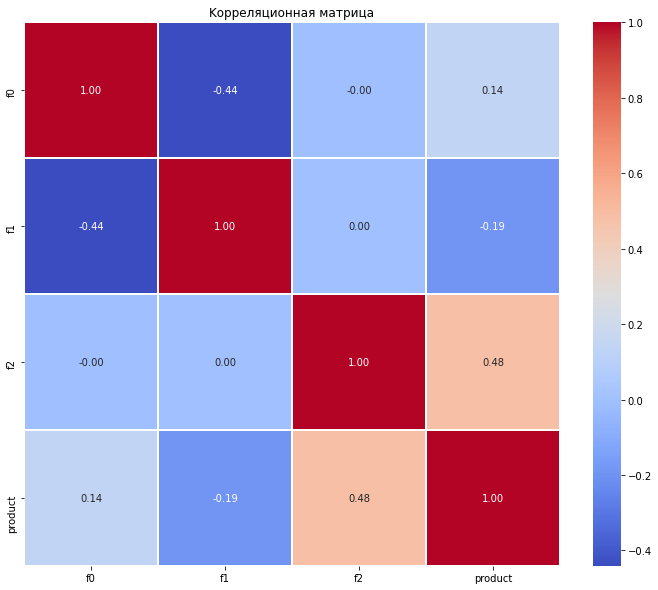

In [34]:
# Визуализируем матрицу 
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_0, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Kорреляционная матрица")
plt.show()


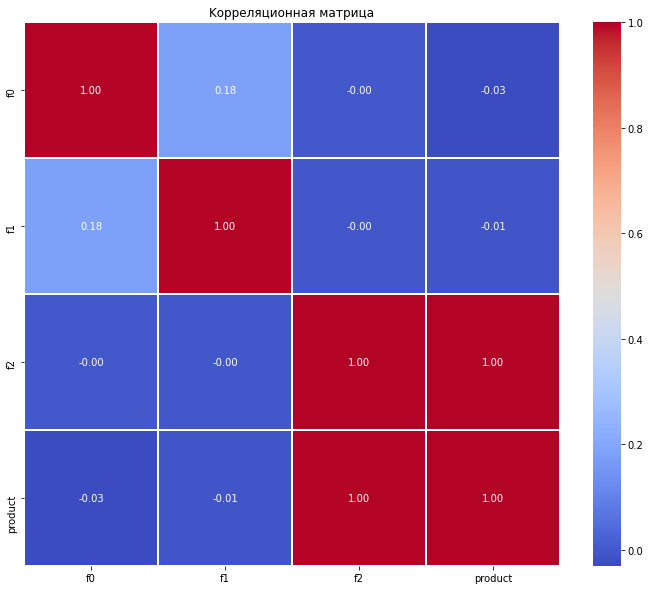

In [35]:
# Визуализируем матрицу 
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_1, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Kорреляционная матрица")
plt.show()

f2 и product: Очень сильная положительная корреляция (0.999397).

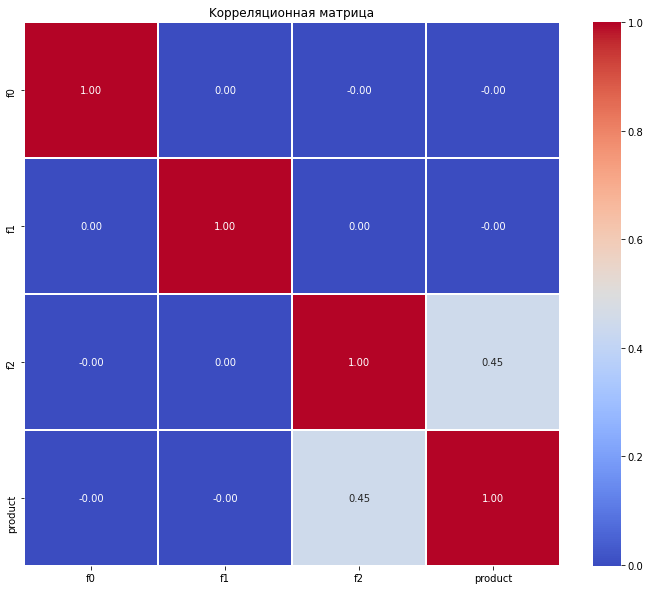

In [36]:
# Визуализируем матрицу 
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_2, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Kорреляционная матрица")
plt.show()

In [37]:
geo_data_0_copy_no_id = geo_data_0_copy.drop('id', axis=1)
geo_data_0_copy_no_id.isna().sum()

f0         0
f1         0
f2         0
product    0
dtype: int64

In [38]:
geo_data_1_copy_no_id = geo_data_1_copy.drop('id', axis=1)
geo_data_1_copy_no_id.isna().sum()

f0         0
f1         0
f2         0
product    0
dtype: int64

In [39]:
geo_data_2_copy_no_id = geo_data_2_copy.drop('id', axis=1)
geo_data_2_copy_no_id.isna().sum()

f0         0
f1         0
f2         0
product    0
dtype: int64

## Обучение и проверка модели

In [40]:
three_geo_data = [geo_data_0_copy_no_id, geo_data_1_copy_no_id, geo_data_2_copy_no_id]
results = {}
X_valid_data = {}  
y_valid_data = {}  
for i, geo_data in enumerate(three_geo_data):
    print(f"Обучение и оценка модели для региона {i}")
    
    # Разделяем на обучающую и валидационную выборки
    X_train, X_test, y_train, y_test = train_test_split(
        geo_data.drop(['product'], axis=1),
        geo_data['product'],
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )
    # Сохраняем валидационные данные
    X_valid_data[f"region_{i}"] = X_test
    y_valid_data[f"region_{i}"] = y_test
    
    # создаём списки с названиями признаков

    num_columns = ['f0', 'f1', 'f2']

    # создаём общий пайплайн для подготовки данных
    data_preprocessor = ColumnTransformer(
            [('num', Pipeline([('scaler', StandardScaler()), #  
                                ('poly', PolynomialFeatures(degree=2, include_bias=False))
                            ]), num_columns)], 
            remainder='passthrough'
        )
    # создаём итоговый пайплайн: подготовка данных и модель
    pipe_final = Pipeline([
        ('preprocessor', data_preprocessor),
        ('models', LinearRegression())
    ])

    param_grid = [
        {
            'models': [Ridge(random_state=RANDOM_STATE)],
            'models__alpha': loguniform(1e-5, 1e5),
            'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()], # Добавлено в pipeline предобработки
            'preprocessor__num__poly__degree': [2, 3], # Степени полинома
            'preprocessor__num__poly__interaction_only': [True, False] # Только взаимодействия
        },
        {
            'models': [LinearRegression()],
            'preprocessor__num__scaler': [StandardScaler(), MinMaxScaler()]
        }
    ]

    randomized_search = RandomizedSearchCV(
        pipe_final,
        param_distributions=param_grid, 
        cv=5,
        scoring='r2',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        n_iter=50  
    )

    # Обучим RandomizedSearchCV
    randomized_search.fit(X_train, y_train)

    # Выведем лучшие параметры
    print("Лучшие параметры:", randomized_search.best_params_)

    # Получим лучшую модель
    best_model = randomized_search.best_estimator_

    # Сделаем предсказания на валидационной выборке
    y_pred = best_model.predict(X_test)

    # Рассчитаем RMSE.  
    rmse = mean_squared_error(y_test, y_pred) ** 0.5 
    # считаем R^2
    r2 = r2_score(y_test, y_pred)
    
    print(f"  RMSE для региона {i}: {rmse:.4f}")
    print(f"  R2 для региона {i}: {r2:.4f}")
    mean_predicted_product = np.mean(y_pred)
    print(f"  Средний запас предсказанного сырья для региона {i}: {mean_predicted_product:.4f}")
    results[f"region_{i}"] = {"RMSE": rmse, "r2": r2, "model": best_model}   

Обучение и оценка модели для региона 0
Лучшие параметры: {'models': Ridge(random_state=42), 'models__alpha': 1.6156325722510982, 'preprocessor__num__poly__degree': 3, 'preprocessor__num__poly__interaction_only': False, 'preprocessor__num__scaler': StandardScaler()}
  RMSE для региона 0: 37.3340
  R2 для региона 0: 0.2890
  Средний запас предсказанного сырья для региона 0: 92.4483
Обучение и оценка модели для региона 1
Лучшие параметры: {'models': Ridge(random_state=42), 'models__alpha': 1.4443169972109657e-05, 'preprocessor__num__poly__degree': 3, 'preprocessor__num__poly__interaction_only': False, 'preprocessor__num__scaler': MinMaxScaler()}
  RMSE для региона 1: 0.7821
  R2 для региона 1: 0.9997
  Средний запас предсказанного сырья для региона 1: 68.7172
Обучение и оценка модели для региона 2
Лучшие параметры: {'models': Ridge(random_state=42), 'models__alpha': 1.4443169972109657e-05, 'preprocessor__num__poly__degree': 3, 'preprocessor__num__poly__interaction_only': False, 'preproces

**Вывод:**
Регион 0:

RMSE: 37.3340 - Относительно высокая ошибка, не очень точные предсказания.
R2: 0.2890 - Низкий коэффициент. Модель объясняет лишь 29% дисперсии целевой переменной.
Средний запас предсказанного сырья: 92.4483 - Довольно высокий средний запас.
В целом, модель для региона 0 показывает не очень хорошее качество предсказаний.

Регион 1:

RMSE: 0.7821 - Очень низкая ошибка, предсказания очень точные.
R2: 0.9997 - Высокий коэффициент детерминации. Модель практически полностью объясняет дисперсию.
Средний запас предсказанного сырья: 68.7172 - Средний запас меньше, чем в других регионах.
Модель для региона 1 показывает отличное качество предсказаний.

Регион 2:

RMSE: 38.8319 - Высокая ошибка, предсказания неточные.
R2: 0.2481 - Низкий коэффициент детерминации, модель плохо объясняет данные.
Средний запас предсказанного сырья: 94.7373 - Самый высокий из всех регионов.
Модель для региона 2 также показывает низкое качество предсказаний.

Качество моделей сильно различается для разных регионов. Модель для региона 1 значительно превосходит модели для регионов 0 и 2.

Регион 1  - наиболее перспективный с точки зрения точности предсказаний:  Регион 1 выделяется своей предсказательной способностью, что делает его привлекательным для дальнейшего анализа и разработки, хотя средний запас предсказанного сырья там ниже.  Высокая точность модели позволяет лучше оценивать риски и прибыль.

Регионы 0 и 2 требуют улучшения моделей: Модели для регионов 0 и 2 требуют доработки, возможно, необходим пересмотр набора признаков, алгоритма моделирования или предобработки данных.  

## Подготовка к расчёту прибыли

In [41]:
# Получение предсказаний 
all_predictions = {} 
pred_products_mean = {}
for i in range(len(three_geo_data)):
    region_name = f"region_{i}"
    model = results[region_name]['model'] 
    X_valid = X_valid_data[region_name]
    y_valid = y_valid_data[region_name] 

    # Делаем предсказания
    predictions = model.predict(X_valid)

    # Сохраняем предсказания
    all_predictions[region_name] = predictions

    
    # Вычисляем средний запас предсказанного сырья
    mean_predicted_product_external = np.mean(predictions)

    # Сохраняем в словаре
    pred_products_mean[region_name] = {'mean_predicted_product': mean_predicted_product_external}

    # Выводим  на экран
    print(f"\n для {region_name}:") 
    print(f"  Средний запас предсказанного сырья (на X_valid): {mean_predicted_product_external:.2f}")

   
    # Добавляем предсказания в DataFrame для текущего региона
    if region_name == "region_0":
        geo_data_0['product_pred'] = pd.NA
        geo_data_0.loc[X_valid.index, 'product_pred'] = predictions
        geo_data_0['product_pred'] = pd.to_numeric(geo_data_0['product_pred'], errors='coerce')
        print (geo_data_0.head(30))  
    elif region_name == "region_1":
        geo_data_1['product_pred'] = pd.NA
        geo_data_1.loc[X_valid.index, 'product_pred'] = predictions
        geo_data_1['product_pred'] = pd.to_numeric(geo_data_1['product_pred'], errors='coerce')
        print (geo_data_1.head(30))
    elif region_name == "region_2":
        geo_data_2['product_pred'] = pd.NA
        geo_data_2.loc[X_valid.index, 'product_pred'] = predictions
        geo_data_2['product_pred'] = pd.to_numeric(geo_data_2['product_pred'], errors='coerce')
        print (geo_data_2.head(30))


 для region_0:
  Средний запас предсказанного сырья (на X_valid): 92.45
       id        f0        f1        f2     product  product_pred
0   txeyh  0.705745 -0.497823  1.221170  105.280062           NaN
1   2acmu  1.334711 -0.340164  4.365080   73.037750           NaN
2   409wp  1.022732  0.151990  1.419926   85.265647           NaN
3   ijlyr -0.032172  0.139033  2.978566  168.620776           NaN
4   xdl7t  1.988431  0.155413  4.751769  154.036647           NaN
5   wx4hy  0.969570  0.489775 -0.735383   64.741541           NaN
6   tl6pl  0.645075  0.530656  1.780266   49.055285           NaN
7   bypu6 -0.400648  0.808337 -5.624670   72.943292           NaN
8   j9oui  0.643105 -0.551583  2.372141  113.356160    102.795307
9   oluzu  2.173381  0.563698  9.441852  127.910945           NaN
10  b8wq6  0.371066 -0.036585  0.009208   70.326617           NaN
11  1yym1  0.015920  1.062729 -0.722248   45.110381           NaN
12  ziypq -0.276476  0.924865  0.095584   89.158678           NaN
13 

In [42]:
#Расчет минимального необходимого объема сырья для безубыточности
def calculate_breakeven_volume(budget=BUDGET, revenue_per_product=REVENUE_PER_PRODUCT, num_best_points=NUM_BEST_POINTS):
       
    # Общий объём сырья для безубыточности
    total_volume = budget / revenue_per_product

    # Объём сырья на одну скважину
    volume_per_well = total_volume / num_best_points
    return volume_per_well

In [43]:
breakeven_volume_per_well = calculate_breakeven_volume()
print(f'Минимальный необходимый объем сырья для безубыточности: {breakeven_volume_per_well:.2f} тыс. баррелей')

Минимальный необходимый объем сырья для безубыточности: 111.11 тыс. баррелей


Средний запас сырья в каждом регионе меньше достаточного объема сырья.
В регионе_0 на 20%, в регионе_1 на 61%, в регионе_2 на 17%

## Расчёт прибыли и рисков 

In [44]:
def profit_calculation(region_data, num_best_points=NUM_BEST_POINTS, revenue_per_product=REVENUE_PER_PRODUCT):
    
    # Выбираем скважины с максимальными значениями предсказаний
    best_boreholes = region_data.nlargest(num_best_points, 'product_pred')

    # Суммируем целевое значение объема сырья для выбранных скважин
    product_sum = best_boreholes['product'].sum()

    # Рассчитываем доход
    revenue = product_sum * revenue_per_product

    # Вычитаем бюджет на разработку
    profit = revenue - BUDGET

    return profit

In [45]:
print(f"Прибыль для region_0: {profit_calculation(geo_data_0):,.2f} тыс.руб.")
print(f"Прибыль для region_1: {profit_calculation(geo_data_1):,.2f} тыс.руб.")
print(f"Прибыль для region_2: {profit_calculation(geo_data_2):,.2f} тыс.руб.")

Прибыль для region_0: 3,529,251.11 тыс.руб.
Прибыль для region_1: 2,415,086.70 тыс.руб.
Прибыль для region_2: 2,568,563.70 тыс.руб.


In [46]:
def bootstrap_profit(region_data, samples=BOOTSTRAP_SAMPLES, num_best_points=NUM_BEST_POINTS):
    
    values = []
    state = np.random.RandomState(12345) 
    for _ in range(samples):
        # Bootstrap: выбираем случайные строки с возвращением
        subsample = region_data.sample(n=NUM_POINTS_EXPLORED, replace=True, random_state=state)  
        profit = profit_calculation(subsample, num_best_points) 
        values.append(profit)
    values = pd.Series(values)
    return values

In [47]:
def analyze_profit(region_data):
   
    values = bootstrap_profit(region_data)

    mean_profit = values.mean()
    lower_bound = values.quantile(0.025) # 2.5 процентиль
    upper_bound = values.quantile(0.975) # 97.5 процентиль

    #Вероятность убытков
    loss_probability = (values < 0).mean()

    print(f"Средняя прибыль: {mean_profit:,.2f} тыс. руб.")
    print(f"95% доверительный интервал: ({lower_bound:,.2f}, {upper_bound:,.2f}) тыс. руб.")
    print(f"Вероятность убытков: {loss_probability:.4f}")

    return mean_profit, lower_bound, upper_bound, loss_probability

In [48]:
# Анализ регионов и выбор лучшего
regions = {
    "region_0": geo_data_0,
    "region_1": geo_data_1,
    "region_2": geo_data_2
}

best_region = None
best_mean_profit = -np.inf

print("Результаты анализа по регионам:")
for region_name, region_data in regions.items():
    print(f"\nАнализ для {region_name}:")
    region_data_with_predictions = region_data.dropna(subset=['product_pred'])
    mean_profit, lower_bound, upper_bound, loss_probability = analyze_profit(region_data_with_predictions)

    if loss_probability < LOSS_PROBABILITY_THRESHOLD and mean_profit > best_mean_profit:
        best_region = region_name
        best_mean_profit = mean_profit

if best_region:
    print(f"\nРекомендуемый регион для разработки: {best_region} со средней прибылью {best_mean_profit:,.2f} тыс. руб.")
else:
    print("\nНет регионов, удовлетворяющих критерию вероятности убытков.")

Результаты анализа по регионам:

Анализ для region_0:
Средняя прибыль: 437,961.98 тыс. руб.
95% доверительный интервал: (-57,624.59, 944,254.59) тыс. руб.
Вероятность убытков: 0.0450

Анализ для region_1:
Средняя прибыль: 440,175.00 тыс. руб.
95% доверительный интервал: (1,492.15, 836,828.13) тыс. руб.
Вероятность убытков: 0.0250

Анализ для region_2:
Средняя прибыль: 569,029.44 тыс. руб.
95% доверительный интервал: (26,413.61, 1,063,721.34) тыс. руб.
Вероятность убытков: 0.0200

Рекомендуемый регион для разработки: region_2 со средней прибылью 569,029.44 тыс. руб.


**Вывод:**

На основании результатов анализа и с учетом вывода о качестве моделей, рекомендуемый к разработке регион 1, несмотря на то, что регион 2 показывает более высокую среднюю прибыль, так как качество модели региона 1 намного выше, что повышает уверенность в полученных данных о прибыльности.

## Чек-лист готовности проекта

Поставьте 'x' в выполненных пунктах. Далее нажмите Shift+Enter.

- [x]  Jupyter Notebook открыт
- [x]  Весь код выполняется без ошибок
- [x]  Ячейки с кодом расположены в порядке исполнения
- [x]  Выполнен шаг 1: данные подготовлены
- [x]  Выполнен шаг 2: модели обучены и проверены
    - [x]  Данные корректно разбиты на обучающую и валидационную выборки
    - [x]  Модели обучены, предсказания сделаны
    - [x]  Предсказания и правильные ответы на валидационной выборке сохранены
    - [x]  На экране напечатаны результаты
    - [x]  Сделаны выводы
- [x]  Выполнен шаг 3: проведена подготовка к расчёту прибыли
    - [x]  Для всех ключевых значений созданы константы Python
    - [x]  Посчитано минимальное среднее количество продукта в месторождениях региона, достаточное для разработки
    - [x]  По предыдущему пункту сделаны выводы
    - [x]  Написана функция расчёта прибыли
- [x]  Выполнен шаг 4: посчитаны риски и прибыль
    - [x]  Проведена процедура *Bootstrap*
    - [x]  Все параметры бутстрепа соответствуют условию
    - [x]  Найдены все нужные величины
    - [x]  Предложен регион для разработки месторождения
    - [x]  Выбор региона обоснован